# Decode Lab - Project 2
## Credit Card Fraud Detection using Supervised Learning  

**STEP 1 - Importing Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 2 - Loading the Dataset**

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


**STEP 3 - Understanding the Dataset**

In [3]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 19898
Number of Columns : 31


In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19898 entries, 0 to 19897
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    19898 non-null  int64  
 1   V1      19898 non-null  float64
 2   V2      19898 non-null  float64
 3   V3      19898 non-null  float64
 4   V4      19898 non-null  float64
 5   V5      19898 non-null  float64
 6   V6      19898 non-null  float64
 7   V7      19898 non-null  float64
 8   V8      19898 non-null  float64
 9   V9      19898 non-null  float64
 10  V10     19898 non-null  float64
 11  V11     19897 non-null  float64
 12  V12     19897 non-null  float64
 13  V13     19897 non-null  float64
 14  V14     19897 non-null  float64
 15  V15     19897 non-null  float64
 16  V16     19897 non-null  float64
 17  V17     19897 non-null  float64
 18  V18     19897 non-null  float64
 19  V19     19897 non-null  float64
 20  V20     19897 non-null  float64
 21  V21     19897 non-null  float64
 22

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,19898.0,15492.416374,10512.066686,0.000000,4536.250000,14796.000000,26220.500000,30633.000000
V1,19898.0,-0.244326,1.889986,-30.552380,-0.959632,-0.302521,1.164473,1.960497
V2,19898.0,0.242420,1.527342,-40.978852,-0.329008,0.220079,0.870117,16.713389
V3,19898.0,0.745774,1.767726,-31.103685,0.309235,0.898672,1.532922,4.101716
V4,19898.0,0.277011,1.466218,-5.172595,-0.636713,0.224608,1.142143,11.927512
V5,19898.0,-0.163264,1.430821,-32.092129,-0.745156,-0.199377,0.341367,34.099309
V6,19898.0,0.092881,1.331029,-23.496714,-0.657306,-0.175434,0.486735,21.393069
V7,19898.0,-0.145279,1.338260,-26.548144,-0.599403,-0.072254,0.448572,34.303177
V8,19898.0,0.022237,1.346813,-41.484823,-0.171779,0.023822,0.279960,20.007208
V9,19898.0,0.636382,1.278839,-7.175097,-0.209565,0.620176,1.409142,10.392889


In [7]:
df.sample(5, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
10452,16994,0.231241,1.410971,0.776108,3.231041,-0.033702,0.545822,-0.990155,-2.781509,-0.204432,...,-1.389380,0.246766,-0.058258,-0.181028,0.488733,0.269191,0.095681,0.266379,17.73,0.0
1512,1177,1.231961,-0.434463,-0.353181,-0.312596,1.433186,3.956628,-1.201919,1.071643,0.797960,...,-0.143435,-0.376046,-0.006577,1.039655,0.413009,0.331772,0.018791,0.020935,11.50,0.0
18467,29526,-0.541704,0.894774,1.412763,1.071169,-0.031391,0.130057,0.703418,0.179867,-0.873971,...,0.273087,0.843726,0.002048,0.234202,-0.237487,-0.203136,0.403987,0.209808,70.99,0.0
9992,14994,-1.316901,1.120667,2.358632,1.906761,-0.555747,1.116259,-1.119159,-2.084095,2.143139,...,1.799586,-1.491249,-0.398756,0.336695,-0.443955,-0.459070,0.399453,0.142167,76.22,0.0
15405,26792,-2.146755,0.940849,2.886889,0.947054,-1.679851,1.054952,-0.306994,0.653848,0.811570,...,0.079149,0.622528,-0.248209,0.500970,0.402139,1.020444,-0.417341,0.040448,104.68,0.0


**STEP 4 - Data Quality Checks**

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df.duplicated().sum()

np.int64(69)

**STEP 5 - Class Distribution Analysis**

In [10]:
df["Class"].value_counts()

,count
Class,
0.0,19812
1.0,85


In [11]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0.0,99.5728
1.0,0.4272


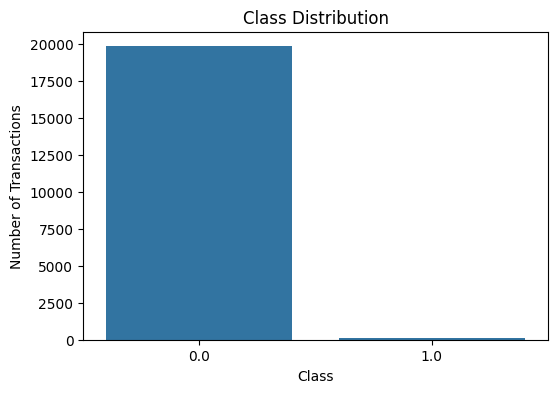

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

**STEP 6 - Data Cleaning**

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [16]:
df.shape

(19828, 31)

In [17]:
df["Class"].value_counts()

,count
Class,
0.0,19743
1.0,85


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(19828, 31)

In [20]:
df["Class"].value_counts()

,count
Class,
0.0,19743
1.0,85


**STEP 7 - Exploratory Data Analysis**

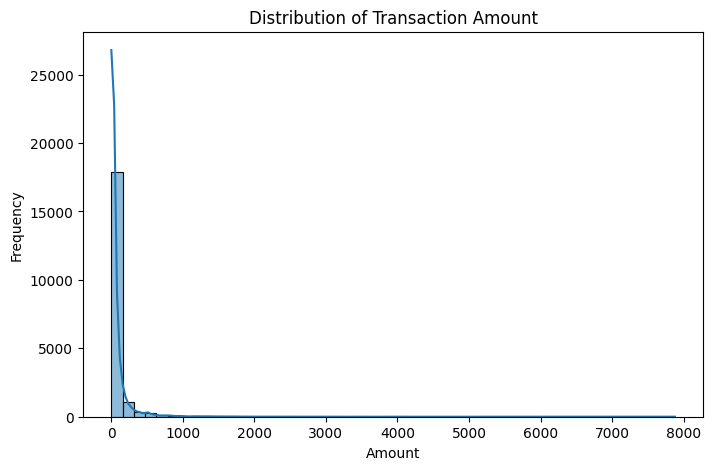

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

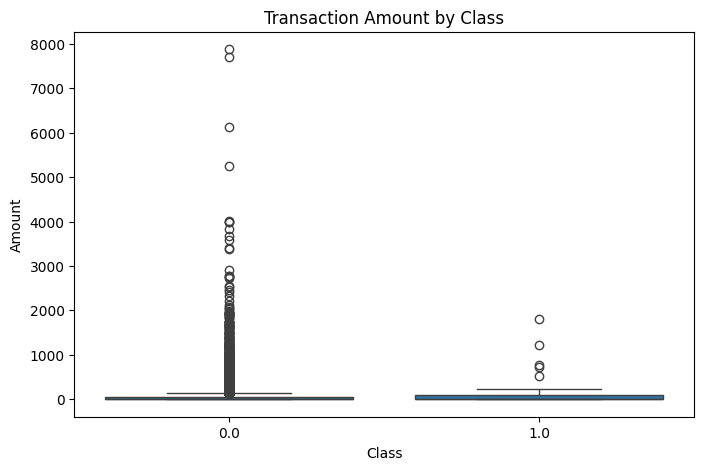

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

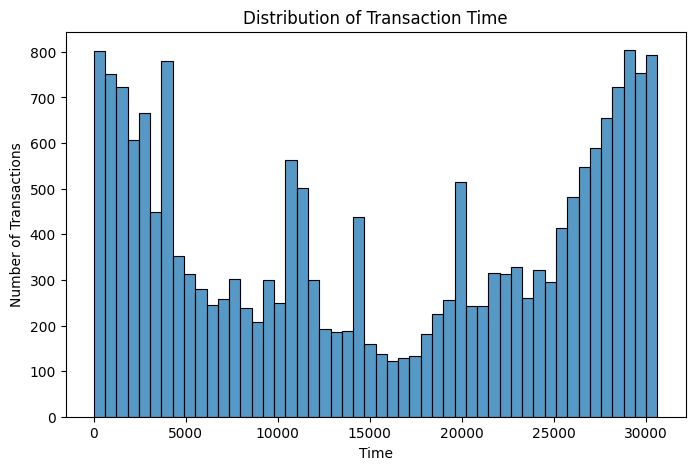

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

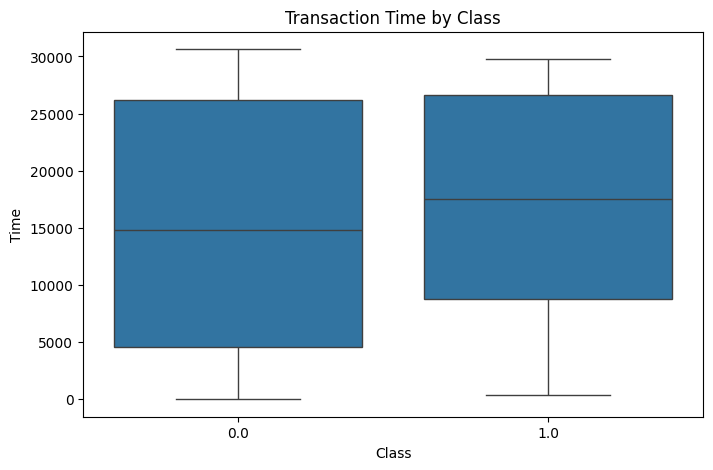

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Time",
    data=df
)

plt.title("Transaction Time by Class")
plt.xlabel("Class")
plt.ylabel("Time")

plt.show()

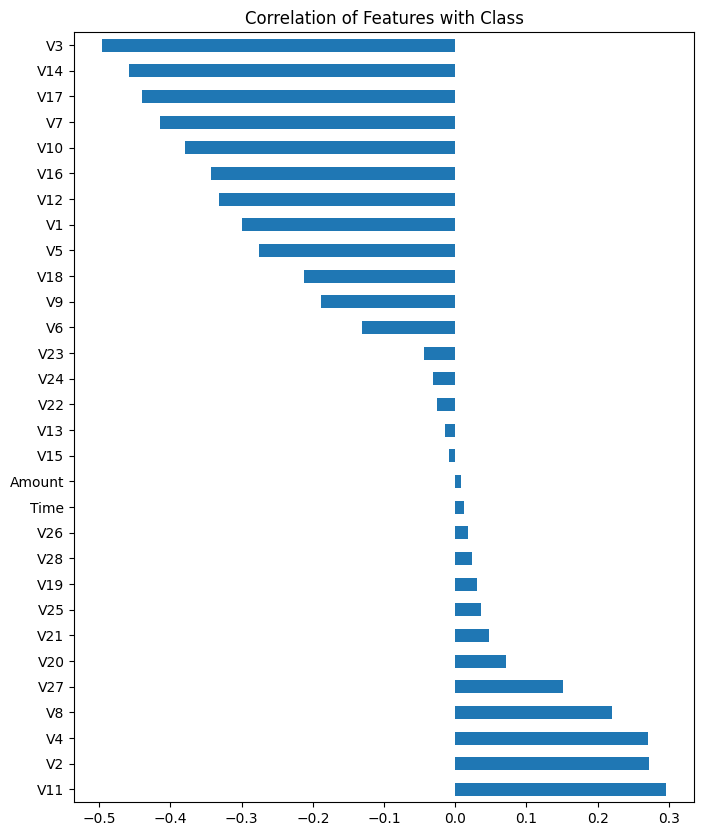

In [25]:
correlation = df.corr()["Class"].sort_values(ascending=False)

correlation

plt.figure(figsize=(8,10))

correlation.drop("Class").plot(kind="barh")

plt.title("Correlation of Features with Class")

plt.show()

**STEP 8 – Data Preparation**

In [26]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (19828, 30)
Target Shape : (19828,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(15862, 30)
(3966, 30)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**STEP 9 – Handling Class Imbalance using SMOTE**

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [31]:
print(y_train.value_counts())

print()

print(y_train_smote.value_counts())

Class
0.0    15794
1.0       68
Name: count, dtype: int64

Class
0.0    15794
1.0    15794
Name: count, dtype: int64


In [32]:
y_train_smote.value_counts(normalize=True) * 100

,proportion
Class,
0.0,50.0
1.0,50.0


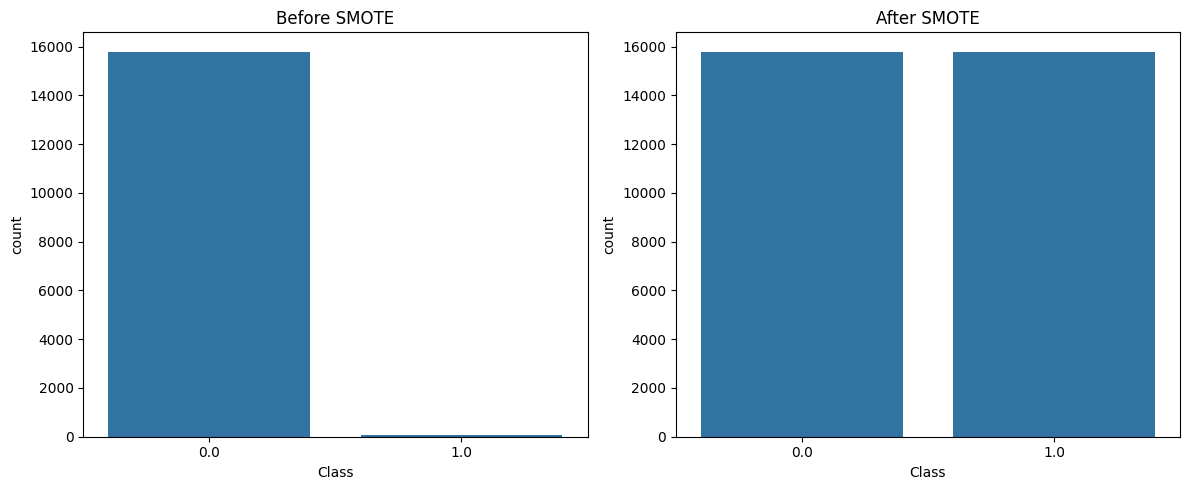

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Before SMOTE")

plt.subplot(1,2,2)
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")

plt.tight_layout()
plt.show()

**STEP 10 – Model Building**

Model 1 – Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

In [35]:
y_pred_lr = lr.predict(X_test)

Model 2 – Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [37]:
y_pred_dt = dt.predict(X_test)

**STEP 11 – Model Evaluation**

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Logistic Regression Evaluation

In [39]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9931921331316188
Precision : 0.3611111111111111
Recall : 0.7647058823529411
F1 Score : 0.49056603773584906


In [40]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      3949
         1.0       0.36      0.76      0.49        17

    accuracy                           0.99      3966
   macro avg       0.68      0.88      0.74      3966
weighted avg       1.00      0.99      0.99      3966



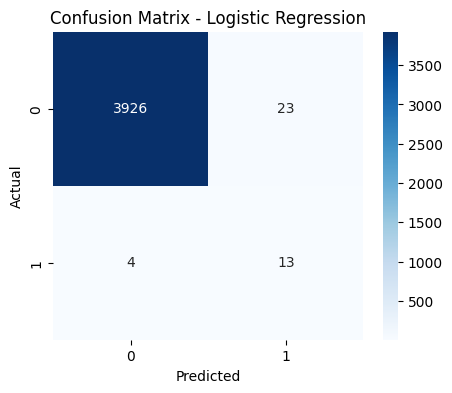

In [41]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Logistic Regression AUC Score: 0.8974572862824542


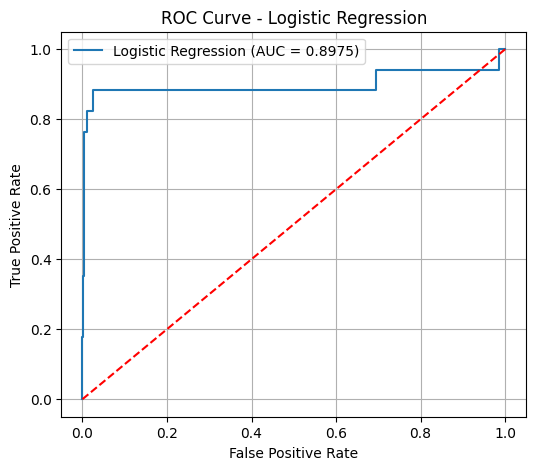

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score


y_prob_lr = lr.predict_proba(X_test)[:, 1]


fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression AUC Score:", auc_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

Decision Tree Evaluation

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.9977307110438729
Precision : 0.7
Recall : 0.8235294117647058
F1 Score : 0.7567567567567568


In [43]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3949
         1.0       0.70      0.82      0.76        17

    accuracy                           1.00      3966
   macro avg       0.85      0.91      0.88      3966
weighted avg       1.00      1.00      1.00      3966



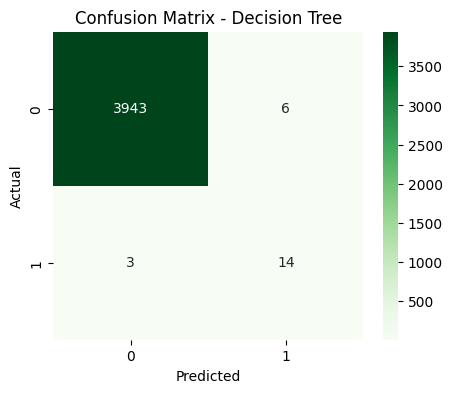

In [44]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Decision Tree AUC Score: 0.9110050198858981


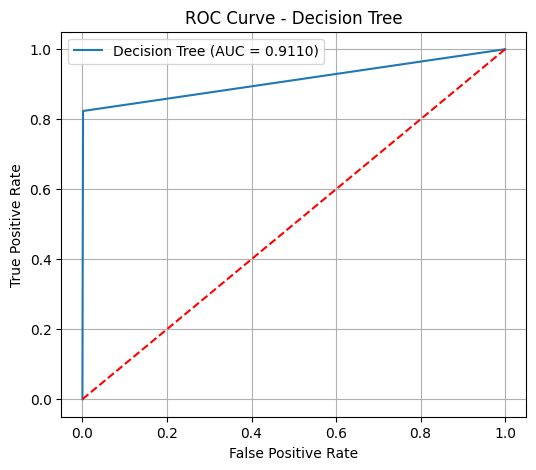

In [46]:
y_prob_dt = dt.predict_proba(X_test)[:,1]


fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)


auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree AUC Score:", auc_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid(True)

plt.show()

Combined ROC Curve

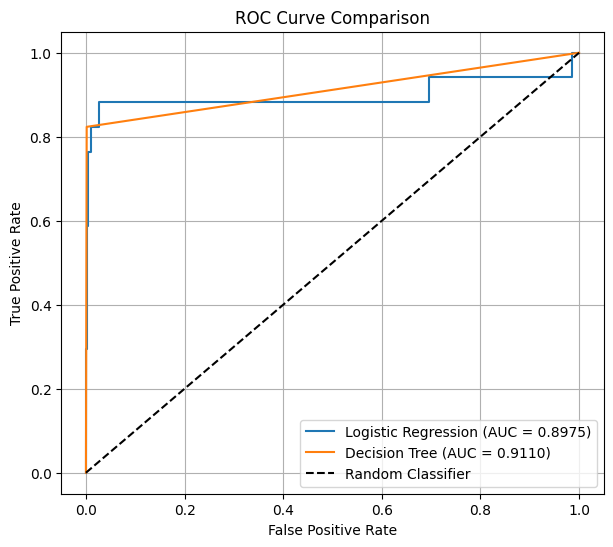

In [47]:
plt.figure(figsize=(7,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')

plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC = {auc_dt:.4f})')

plt.plot([0,1],[0,1],
         linestyle='--',
         color='black',
         label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

**STEP 12 – Model Comparison**

In [48]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.993192,0.361111,0.764706,0.490566
1,Decision Tree,0.997731,0.700000,0.823529,0.756757


In [49]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ],
    "AUC": [
        auc_lr,
        auc_dt
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.993192,0.361111,0.764706,0.490566,0.897457
1,Decision Tree,0.997731,0.700000,0.823529,0.756757,0.911005


## **Conclusion**

- The dataset contained a severe class imbalance with fraudulent transactions representing less than 1% of the data.
- Duplicate records were removed and missing values were handled before model training.
- SMOTE was applied to generate synthetic fraud samples and balance the training dataset.
- Logistic Regression and Decision Tree models were trained on the balanced dataset.
- Based on Accuracy, Precision, Recall and F1-score, the Decision Tree outperformed Logistic Regression.
- Therefore, the Decision Tree model is selected as the better model for this fraud detection task.